# 07 regression — predicting CO2 emissions


In [1]:
from pathlib import Path

# Works whether the notebook is run from the project root or from the notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from collections import Counter

from xgboost import XGBRegressor
import shap

## load processed dataset

In [3]:
df = pd.read_csv(DATA_DIR / "processed_carbon_dataset.csv")

feature_cols = [  # unified 15-feature set
    "electricity_kwh_per_month", "natural_gas_therms_per_month",
    "fuel_liters_per_month", "car_km_per_month",
    "public_transport_km_per_month", "meat_kg_per_month",
    "energy_per_person", "gas_per_person",
    "fuel_per_person", "car_per_person",
    "transport_ratio", "meat_per_person",
    "food_per_person", "waste_per_person", "log_income"
]

X = df[feature_cols]
y = df["estimated_co2_kg_per_month"]  # continuous regression target

print("target range:", y.min().round(1), "~", y.max().round(1), "kg/month")  # sanity check target scale
print("target mean :", y.mean().round(1))


target range: 493.7 ~ 2576.2 kg/month
target mean : 1468.4


## target distribution

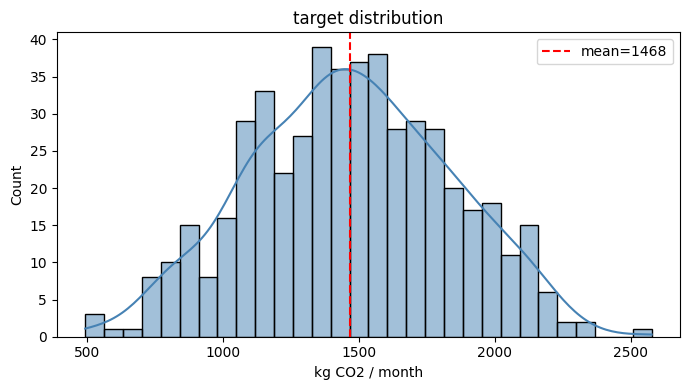

In [4]:
plt.figure(figsize=(7, 4))
sns.histplot(y, bins=30, kde=True, color="steelblue")
plt.axvline(y.mean(), color="red", linestyle="--", label=f"mean={y.mean():.0f}")  # mean reference line
plt.xlabel("kg CO2 / month")
plt.title("target distribution")
plt.legend()
plt.tight_layout()
plt.show()

Roughly normal, same as seen in notebook 01.

## train test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # no stratify needed for continuous target
)
print("train:", X_train.shape, "  test:", X_test.shape)

train: (400, 15)   test: (100, 15)


## helper — evaluation

In [6]:
def evaluate(name, y_true, y_pred):  # shared metric reporter: RMSE / MAE / R²
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # RMSE in original kg CO2 units
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<25}  RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []  # accumulate dicts for comparison table

## linear regression (baseline)

In [7]:
pipe_lr = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])  # baseline: OLS with standard scaling
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
results.append(evaluate("Linear Regression", y_test, y_pred_lr))

Linear Regression          RMSE=24.63  MAE=19.98  R²=0.9957


## ridge regression

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

pipe_ridge = Pipeline([("scaler", StandardScaler()), ("model", Ridge())])  # L2 regularisation; shrinks coefficients
search_ridge = GridSearchCV(pipe_ridge, {"model__alpha": [0.01, 0.1, 1, 10, 100]},  # alpha: regularisation strength
                             cv=cv, scoring="r2")
search_ridge.fit(X_train, y_train)

best_ridge = search_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
print("best alpha:", search_ridge.best_params_)
results.append(evaluate("Ridge", y_test, y_pred_ridge))

best alpha: {'model__alpha': 0.1}
Ridge                      RMSE=24.63  MAE=19.98  R²=0.9957


## lasso regression

In [9]:
pipe_lasso = Pipeline([("scaler", StandardScaler()), ("model", Lasso(max_iter=10000))])  # L1 regularisation; drives weak coefficients to zero
search_lasso = GridSearchCV(pipe_lasso, {"model__alpha": [0.01, 0.1, 1, 10, 100]},
                             cv=cv, scoring="r2")
search_lasso.fit(X_train, y_train)

best_lasso = search_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)
print("best alpha:", search_lasso.best_params_)
results.append(evaluate("Lasso", y_test, y_pred_lasso))

lasso_coef = pd.Series(  # zero coefficients = features eliminated by Lasso
    best_lasso.named_steps["model"].coef_,
    index=feature_cols
).sort_values(key=abs, ascending=False)
print("\nlasso coefficients:")
print(lasso_coef)

best alpha: {'model__alpha': 0.1}
Lasso                      RMSE=24.52  MAE=19.95  R²=0.9957

lasso coefficients:
natural_gas_therms_per_month     231.899616
meat_kg_per_month                161.794459
electricity_kwh_per_month        137.596399
fuel_liters_per_month            134.050220
car_km_per_month                 114.252126
waste_per_person                  43.155967
public_transport_km_per_month     17.554811
energy_per_person                -13.185834
meat_per_person                  -10.258164
gas_per_person                    -6.546687
fuel_per_person                   -4.794018
car_per_person                    -3.999263
food_per_person                   -3.299380
log_income                         0.976092
transport_ratio                    0.000000
dtype: float64


## alpha selection path (Ridge / Lasso)

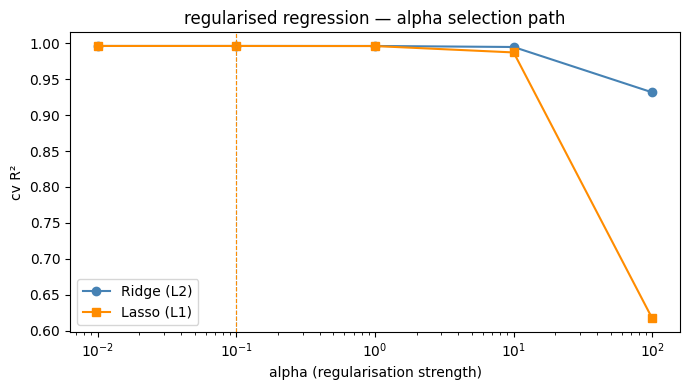

In [10]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_scores = search_ridge.cv_results_["mean_test_score"]  # CV R² per alpha
lasso_scores = search_lasso.cv_results_["mean_test_score"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(alphas, ridge_scores, "o-", label="Ridge (L2)", color="steelblue")
ax.semilogx(alphas, lasso_scores, "s-", label="Lasso (L1)", color="darkorange")
ax.axvline(search_ridge.best_params_["model__alpha"], color="steelblue", linestyle="--", linewidth=0.8)
ax.axvline(search_lasso.best_params_["model__alpha"], color="darkorange", linestyle="--", linewidth=0.8)
ax.set_xlabel("alpha (regularisation strength)")
ax.set_ylabel("cv R²")
ax.set_title("regularised regression — alpha selection path")
ax.legend()
plt.tight_layout()
plt.show()

## xgboost regressor

In [11]:
param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_reg = XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)
search_xgb = RandomizedSearchCV(xgb_reg, param_grid_xgb, n_iter=30, cv=cv,  # 30 random hyperparam combinations
                                 scoring="r2", random_state=42, n_jobs=-1)
search_xgb.fit(X_train, y_train)

best_xgb = search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print("best params:", search_xgb.best_params_)
results.append(evaluate("XGBoost Regressor", y_test, y_pred_xgb))

best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
XGBoost Regressor          RMSE=60.98  MAE=49.31  R²=0.9734


## model comparison

                      RMSE      MAE      R2
model                                      
Linear Regression  24.6296  19.9779  0.9957
Ridge              24.6259  19.9762  0.9957
Lasso              24.5180  19.9476  0.9957
XGBoost Regressor  60.9762  49.3100  0.9734


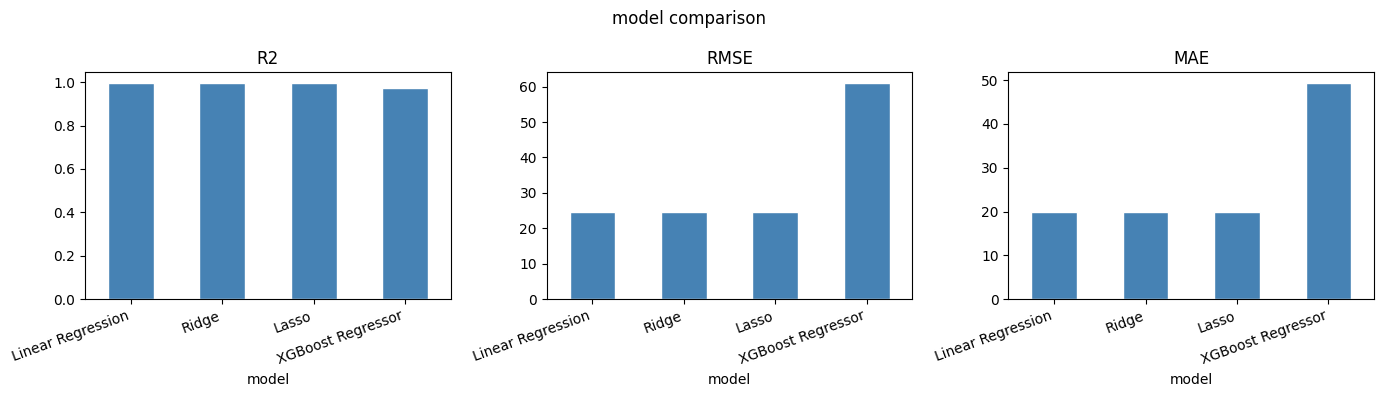

In [12]:
results_df = pd.DataFrame(results).set_index("model").round(4)
results_df = results_df.sort_values("R2", ascending=False)  # rank by R²: higher = better fit
print(results_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["R2", "RMSE", "MAE"]):
    results_df[metric].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(metric)
    ax.set_xticklabels(results_df.index, rotation=20, ha="right")

plt.suptitle("model comparison")
plt.tight_layout()
plt.show()

Linear models clearly beat XGBoost here.

## winner selection

In [13]:
# select best model by voting across all three metrics
winner_r2   = results_df["R2"].idxmax()    # highest R²
winner_rmse = results_df["RMSE"].idxmin()  # lowest RMSE
winner_mae  = results_df["MAE"].idxmin()   # lowest MAE

votes = [winner_r2, winner_rmse, winner_mae]
print("best R²  :", winner_r2)
print("best RMSE:", winner_rmse)
print("best MAE :", winner_mae)

best_model_name = Counter(votes).most_common(1)[0][0]
print("overall winner:", best_model_name)

model_registry = {
    "Linear Regression": (pipe_lr,   y_pred_lr),
    "Ridge":             (best_ridge, y_pred_ridge),
    "Lasso":             (best_lasso, y_pred_lasso),
    "XGBoost Regressor": (best_xgb,   y_pred_xgb),
}

best_pipeline, y_pred_best = model_registry[best_model_name]
print(f"using {best_model_name} for all subsequent analysis")


best R²  : Linear Regression
best RMSE: Lasso
best MAE : Lasso
overall winner: Lasso
using Lasso for all subsequent analysis


Linear models win (R² ~0.996). XGBoost does worse (R² 0.97) — the CO2 target is essentially a linear function of consumption, so linear regression fits it almost perfectly.

## actual vs predicted & residual distribution

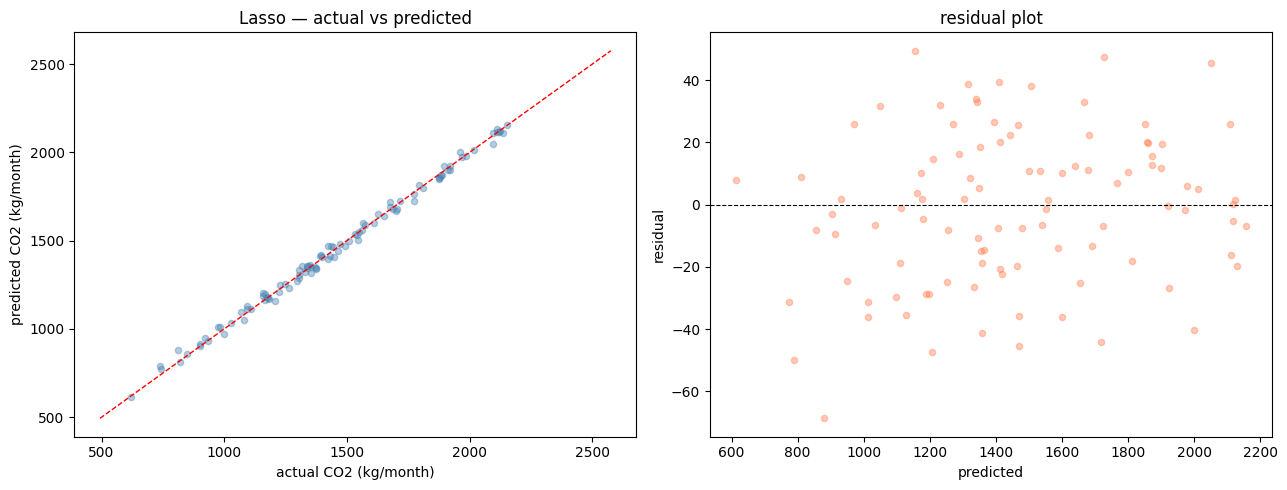

In [14]:
# actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.4, s=20, color="steelblue")
lims = [y.min(), y.max()]
axes[0].plot(lims, lims, "r--", linewidth=1)  # perfect-prediction diagonal reference
axes[0].set_xlabel("actual CO2 (kg/month)")
axes[0].set_ylabel("predicted CO2 (kg/month)")
axes[0].set_title(f"{best_model_name} — actual vs predicted")

residuals = y_test - y_pred_best  # signed error: positive = under-prediction
axes[1].scatter(y_pred_best, residuals, alpha=0.4, s=20, color="coral")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")  # zero-residual reference line
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("residual")
axes[1].set_title("residual plot")

plt.tight_layout()
plt.show()

Points sit tight on the diagonal; residuals are small and centred at 0.

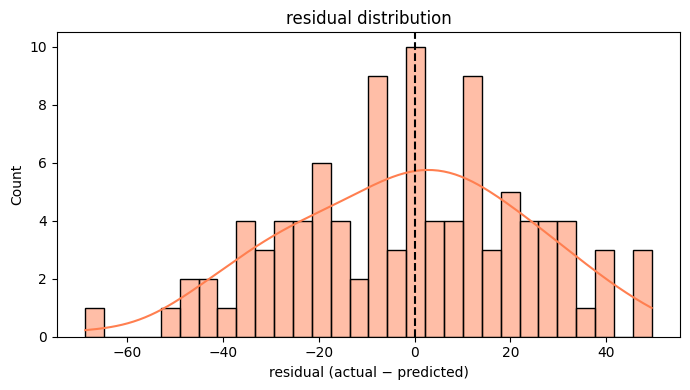

residual mean: -1.351
residual std : 24.604


In [15]:
# residual distribution
plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=30, kde=True, color="coral")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("residual (actual − predicted)")
plt.title("residual distribution")
plt.tight_layout()
plt.show()

print("residual mean:", residuals.mean().round(3))  # near-zero mean → no systematic bias
print("residual std :", residuals.std().round(3))   # std ≈ RMSE for unbiased model

## cross-validation

In [16]:
cv_r2   = cross_val_score(best_pipeline, X_train, y_train, cv=cv, scoring="r2")
cv_rmse = cross_val_score(best_pipeline, X_train, y_train, cv=cv,
                           scoring="neg_root_mean_squared_error")  # sklearn negates so higher = better
print(f"CV R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"CV RMSE: {(-cv_rmse).mean():.2f} ± {(-cv_rmse).std():.2f}")  # negate back to positive RMSE

CV R²  : 0.9962 ± 0.0010
CV RMSE: 21.65 ± 1.28


## feature importance

C:\Users\YJ\AppData\Local\Temp\ipykernel_17172\2343670128.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi, x="importance", y="feature", palette="viridis")


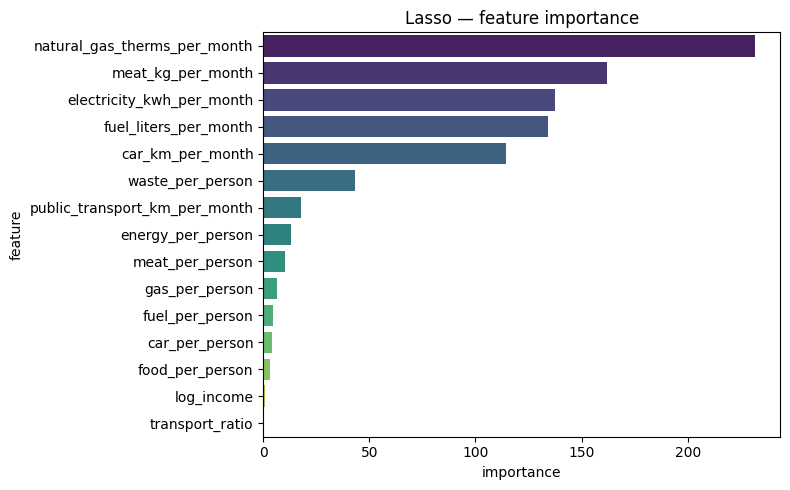

In [17]:
if hasattr(best_pipeline, "feature_importances_"):  # tree models only
    fi = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_pipeline.feature_importances_  # gain-based importance (built-in XGBoost)
    }).sort_values("importance", ascending=False)
elif hasattr(best_pipeline, "named_steps"):
    fi = pd.DataFrame({
        "feature": feature_cols,
        "importance": np.abs(best_pipeline.named_steps["model"].coef_)  # linear: abs(coef) as proxy
    }).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=fi, x="importance", y="feature", palette="viridis")
plt.title(f"{best_model_name} — feature importance")
plt.tight_layout()
plt.show()

Gas and meat lead again, consistent across all notebooks.

## shap — global summary & beeswarm

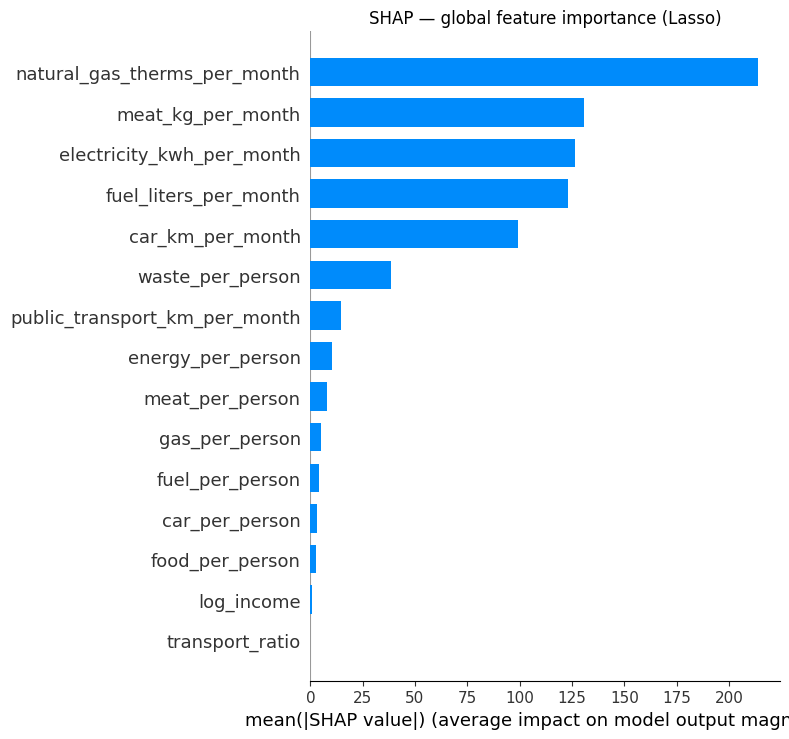

In [18]:
if hasattr(best_pipeline, "named_steps") and isinstance(best_pipeline.named_steps.get("model"), (LinearRegression, Ridge, Lasso)):
    scaler         = best_pipeline.named_steps["scaler"]
    linear_mod     = best_pipeline.named_steps["model"]
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    explainer_shap = shap.LinearExplainer(linear_mod, X_train_scaled)
    shap_values    = explainer_shap.shap_values(X_test_scaled)
    shap_data      = pd.DataFrame(X_test_scaled, columns=feature_cols)
else:
    explainer_shap = shap.TreeExplainer(best_pipeline)  # exact Tree SHAP for regression
    shap_values    = explainer_shap.shap_values(X_test)  # 1D per sample (regression = single output)
    shap_data      = X_test

shap.summary_plot(shap_values, shap_data, plot_type="bar", max_display=len(feature_cols), show=False)
plt.title(f"SHAP — global feature importance ({best_model_name})")
plt.tight_layout()
plt.show()

## shap — beeswarm

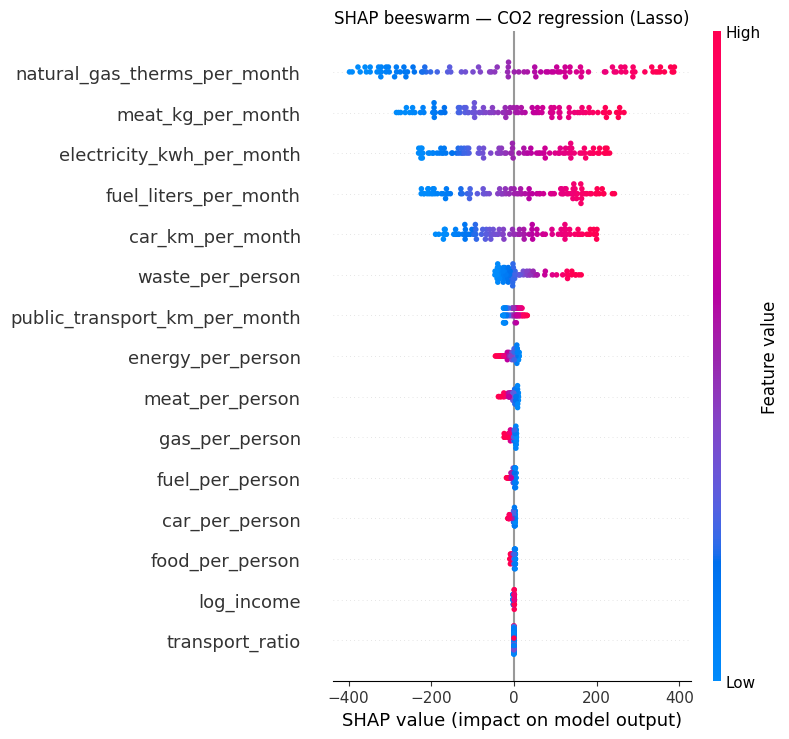

In [19]:
shap.summary_plot(shap_values, shap_data, max_display=len(feature_cols), show=False)
plt.title(f"SHAP beeswarm — CO2 regression ({best_model_name})")
plt.tight_layout()
plt.show()

## shap — waterfall

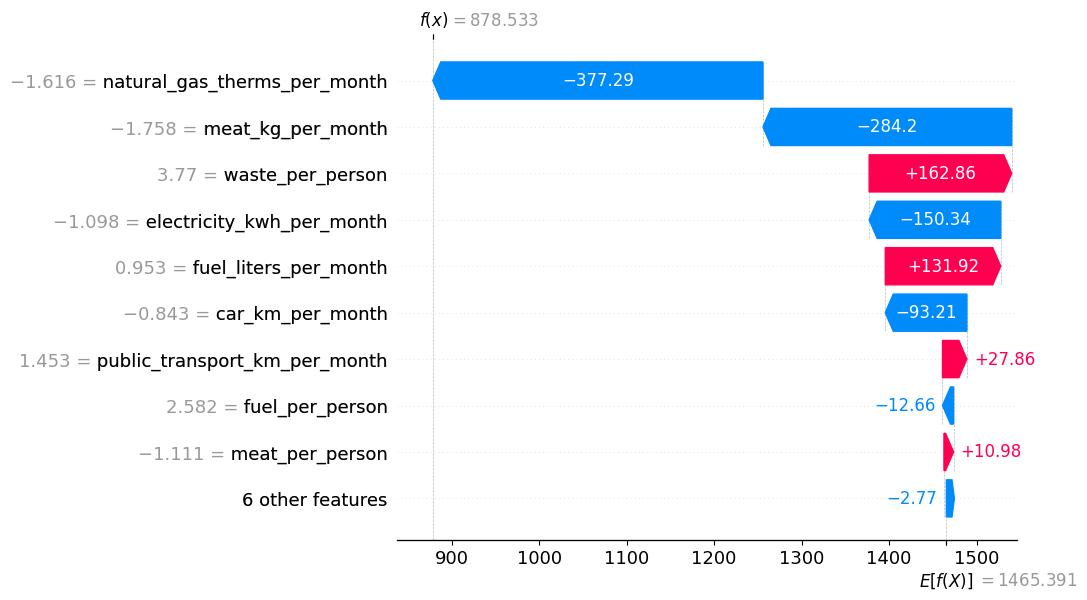

In [20]:
worst_idx = np.abs(residuals.values).argmax()  # largest absolute error sample for diagnostic
shap.waterfall_plot(
    shap.Explanation(
        values       = shap_values[worst_idx],
        base_values  = explainer_shap.expected_value,
        data         = shap_data.iloc[worst_idx],
        feature_names= feature_cols
    )
)

## coefficient plot

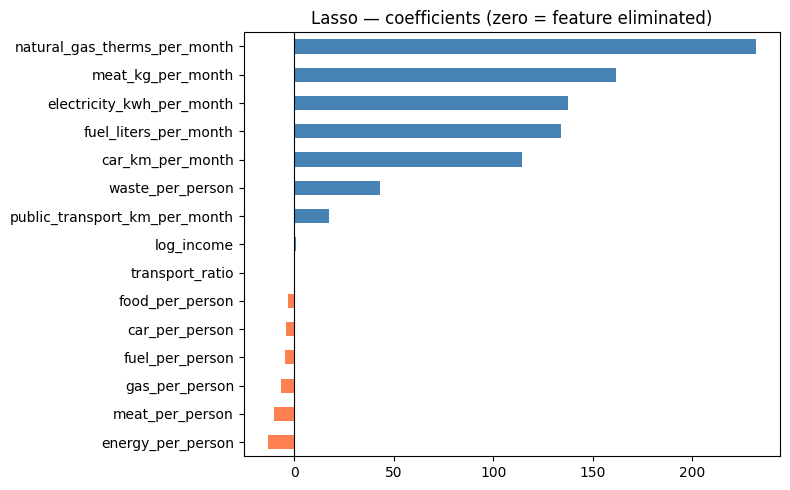

In [21]:
if hasattr(best_pipeline, "named_steps") and isinstance(best_pipeline.named_steps.get("model"), (LinearRegression, Ridge, Lasso)):
    coef_plot = pd.Series(
        best_pipeline.named_steps["model"].coef_,
        index=feature_cols
    ).sort_values()
    colors = ["coral" if v < 0 else "steelblue" for v in coef_plot]  # coral = negative; blue = positive effect
    plt.figure(figsize=(8, 5))
    coef_plot.plot(kind="barh", color=colors)
    plt.axvline(0, color="black", linewidth=0.8)  # features at zero were eliminated by Lasso
    plt.title(f"{best_model_name} — coefficients (zero = feature eliminated)")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} has no coefficients — see feature importance plot above")

## prediction example

In [22]:
new_household = pd.DataFrame([{  # hardcoded demo household for inference (all 15 features)
    "electricity_kwh_per_month":    600,
    "natural_gas_therms_per_month": 80,
    "fuel_liters_per_month":        120,
    "car_km_per_month":             900,
    "public_transport_km_per_month": 100,
    "meat_kg_per_month":            12,
    "energy_per_person":            150,
    "gas_per_person":               20,
    "fuel_per_person":              30,
    "car_per_person":               225,
    "transport_ratio":              9.0,
    "meat_per_person":              3,
    "food_per_person":              300,
    "waste_per_person":             15,
    "log_income":                   11.5
}])[feature_cols]  # reorder to match training feature order

pred = best_pipeline.predict(new_household)[0]  # single-row inference
print(f"predicted CO2 emission: {pred:.1f} kg / month")
print(f"equivalent to approx.  {pred * 12 / 1000:.2f} tonnes CO2 / year")  # monthly -> annual tonne conversion

predicted CO2 emission: 1541.9 kg / month
equivalent to approx.  18.50 tonnes CO2 / year


## save model for deployment

In [23]:
import joblib

best_pipeline.fit(X, y)  # full dataset
joblib.dump(best_pipeline, MODELS_DIR / "model_co2_regressor.pkl")
joblib.dump(feature_cols, MODELS_DIR / "features_co2_regressor.pkl")
print(f"saved model_co2_regressor.pkl ({best_model_name}) + features_co2_regressor.pkl")


saved model_co2_regressor.pkl (Lasso) + features_co2_regressor.pkl
